In [3]:
import pandas as pd # type: ignore
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"D:\Gayathri\Bachelor's of Engineering\Internship\Encryptix\advertising.csv")
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [6]:
df.shape

(200, 4)

In [7]:
#Data Cleaning and Pre-processing
df['TV'].fillna(df['TV'].mean(), inplace=True)
df['Radio'].fillna(df['Radio'].mean(), inplace=True)
df['Newspaper'].fillna(df['Newspaper'].mean(), inplace=True)
df['Sales'].fillna(df['Sales'].mean(), inplace=True)

df = df.drop_duplicates()

In [8]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
df[['TV']] = scaler.fit_transform(df[['TV']])
df[['Radio']] = scaler.fit_transform(df[['Radio']])
df[['Newspaper']] = scaler.fit_transform(df[['Newspaper']])
df[['Sales']] = scaler.fit_transform(df[['Sales']])

In [11]:
from sklearn.model_selection import train_test_split


In [12]:
X = df[['Newspaper']]  # Features: You can add more features here
y = df['Sales']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [14]:
y_pred=model.predict(X_test)


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

In [16]:
r2 = r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [17]:
print(f'Mean Absolute Error (MAE): {mae:.5f}')
print(f'R-squared (R²): {r2:.5f}')

Mean Absolute Error (MAE): 0.90383
R-squared (R²): 0.00459


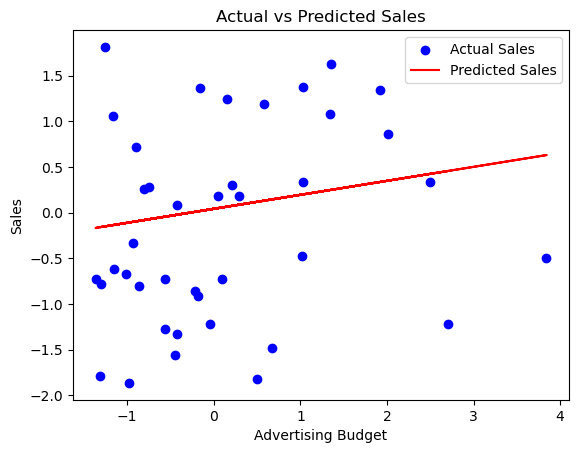

In [18]:
plt.scatter(X_test, y_test, color='blue', label='Actual Sales')
plt.plot(X_test, y_pred, color='red', label='Predicted Sales')
plt.xlabel('Advertising Budget')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()